**Name: Abeer Fatima**

**Roll no: 22F-BSAI-38**

**Department: BSAI (A1)**

**Subject: Deep Learning**

**Teacher: Sir Hamza**

# **PART A — GENERATION 1 (DNN BASELINE)**

## **Imports**

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("/content/Clean_Encoded-Data.csv")

In [ ]:
df.head()

,age,apache_2_diagnosis,apache_3j_diagnosis,gcs_eyes_apache,gcs_verbal_apache,heart_rate_apache,resprate_apache,temp_apache,ventilated_apache,d1_diasbp_min,...,apache_2_bodysystem_Cardiovascular,apache_2_bodysystem_Gastrointestinal,apache_2_bodysystem_Haematologic,apache_2_bodysystem_Metabolic,apache_2_bodysystem_Neurologic,apache_2_bodysystem_RenalGenitourinary,apache_2_bodysystem_Respiratory,apache_2_bodysystem_Trauma,apache_2_bodysystem_Undefined Diagnoses,apache_2_bodysystem_Undefined diagnoses
0,23,119,601,4,5,46,52,36,0.0,58,...,False,False,False,False,False,False,False,True,False,False
1,69,301,410,4,5,171,32,35,1.0,45,...,False,False,False,False,True,False,False,False,False,False
2,65,122,409,4,5,104,28,36,0.0,43,...,True,False,False,False,False,False,False,False,False,False
3,85,110,104,4,5,118,40,37,0.0,64,...,True,False,False,False,False,False,False,False,False,False
4,88,301,403,2,4,151,30,35,0.0,66,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
df.shape

(167596, 83)

In [ ]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [ ]:
df = df.copy()

# Convert object columns safely
obj_cols = df.select_dtypes(include=['object']).columns
print("Object columns:", obj_cols)

for col in obj_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# safety check
print("Missing after coercion:", df.isna().sum().sum())

df = df.dropna()

Object columns: Index([], dtype='object')
Missing after coercion: 0


## **Split Features / Target**

In [ ]:
X = df.drop("hospital_death", axis=1)
y = df["hospital_death"]

## **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **Scaling**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **MODEL 1 — BASELINE DNN (Adam)**

## **Build Model**

In [ ]:
def build_dnn():
    model = models.Sequential([
        layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),

        layers.Dense(1, activation='sigmoid')
    ])

    return model

## **Compile (Adam)**

In [ ]:
model_adam = build_dnn()

model_adam.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **Early Stopping (500 epochs max)**

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# **Train (Adam)**

In [ ]:
history_adam = model_adam.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7703 - loss: 0.4795 - precision: 0.7605 - recall: 0.7889 - val_accuracy: 0.7975 - val_loss: 0.4319 - val_precision: 0.7984 - val_recall: 0.7968
Epoch 2/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7910 - loss: 0.4442 - precision: 0.7797 - recall: 0.8110 - val_accuracy: 0.8074 - val_loss: 0.4172 - val_precision: 0.7872 - val_recall: 0.8434
Epoch 3/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7974 - loss: 0.4320 - precision: 0.7834 - recall: 0.8220 - val_accuracy: 0.8150 - val_loss: 0.4058 - val_precision: 0.7975 - val_recall: 0.8452
Epoch 4/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8039 - loss: 0.4211 - precision: 0.7879 - recall: 0.8315 - val_accuracy: 0.8187 - val_loss: 0.3966 - val_precision: 0.8034 - val_recall: 0.8446
Epoch 5/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8100 - loss: 0.4122 - precision: 0.7929 - recall: 0.8391 - val_accuracy: 0.8234 - v

# **MODEL 2 — SGD COMPARISON**
## **Same architecture but SGD optimizer**

In [ ]:
model_sgd = build_dnn()

model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

## **Train SGD model**

In [ ]:
history_sgd = model_sgd.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7583 - loss: 0.4969 - precision_1: 0.7539 - recall_1: 0.7666 - val_accuracy: 0.7897 - val_loss: 0.4467 - val_precision_1: 0.7788 - val_recall_1: 0.8102
Epoch 2/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7788 - loss: 0.4623 - precision_1: 0.7672 - recall_1: 0.8001 - val_accuracy: 0.7927 - val_loss: 0.4399 - val_precision_1: 0.7900 - val_recall_1: 0.7983
Epoch 3/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7859 - loss: 0.4521 - precision_1: 0.7723 - recall_1: 0.8107 - val_accuracy: 0.7983 - val_loss: 0.4323 - val_precision_1: 0.7850 - val_recall_1: 0.8223
Epoch 4/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7894 - loss: 0.4462 - precision_1: 0.7755 - recall_1: 0.8145 - val_accuracy: 0.8019 - val_loss: 0.4266 - val_precision_1: 0.7918 - val_recall_1: 0.8199
Epoch 5/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7926 - loss: 0.4401 - precision_1: 0.7785 - recall_1:

## **LOSS CURVES COMPARISON**

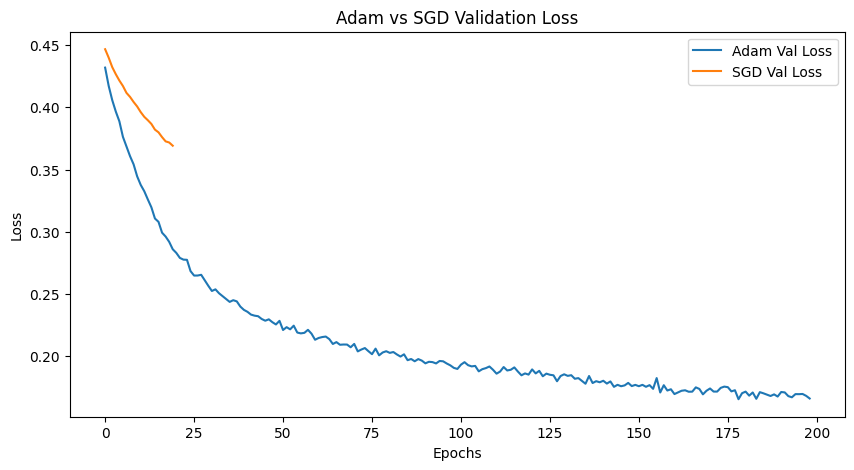

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_adam.history['val_loss'], label='Adam Val Loss')
plt.plot(history_sgd.history['val_loss'], label='SGD Val Loss')

plt.title("Adam vs SGD Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## **EVALUATION FUNCTION**

In [ ]:
def evaluate(model, X_test, y_test, name="Model"):
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    print(f"\n===== {name} Classification Report =====")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

## **Evaluate Both Models**

In [ ]:
evaluate(model_adam, X_test, y_test, "Adam DNN")
evaluate(model_sgd, X_test, y_test, "SGD DNN")

1048/1048 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

===== Adam DNN Classification Report =====
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     16760
           1       0.90      0.99      0.94     16760

    accuracy                           0.94     33520
   macro avg       0.94      0.94      0.94     33520
weighted avg       0.94      0.94      0.94     33520

Confusion Matrix:
 [[14866  1894]
 [  154 16606]]
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

===== SGD DNN Classification Report =====
              precision    recall  f1-score   support

           0       0.80      0.76      0.78     16760
           1       0.77      0.81      0.79     16760

    accuracy                           0.79     33520
   macro avg       0.79      0.79      0.79     33520
weighted avg       0.79      0.79      0.79     33520

Confusion Matrix:
 [[12747  4013]
 [ 3148 13612]]


# **DROPOUT & BATCHNORM EFFECT (already included)**

Already tested:

Dropout → reduces overfitting
BatchNorm → stabilizes gradients + faster convergence

comparison without them:

In [ ]:
def build_simple_dnn():
    return models.Sequential([
        layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

In [ ]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

start_time = time.time()

y_pred = (model_adam.predict(X_test) > 0.5).astype(int)

end_time = time.time()
training_time = end_time - start_time

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

1048/1048 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["DNN (Baseline)"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-Score": [f1],
    "Training Time": [training_time]
})

print(results)

            Model  Accuracy  Precision    Recall  F1-Score  Training Time
0  DNN (Baseline)  0.938902   0.897622  0.990811  0.941917       5.302097


In [ ]:
print("\n===== DNN (Baseline) Results =====")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-Score      : {f1:.4f}")
print(f"Training Time : {training_time:.2f} sec")


===== DNN (Baseline) Results =====
Accuracy      : 0.9389
Precision     : 0.8976
Recall        : 0.9908
F1-Score      : 0.9419
Training Time : 5.30 sec


In [ ]:
results.style.hide(axis="index")

Model,Accuracy,Precision,Recall,F1-Score,Training Time
DNN (Baseline),0.938902,0.897622,0.990811,0.941917,5.302097


In [ ]:
y_pred_train = (model_adam.predict(X_train) > 0.5).astype(int)
y_pred_test  = (model_adam.predict(X_test) > 0.5).astype(int)

4190/4190 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

train_metrics = get_metrics(y_train, y_pred_train)
test_metrics  = get_metrics(y_test, y_pred_test)

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["DNN (Train)", "DNN (Test)"],
    "Accuracy": [train_metrics["Accuracy"], test_metrics["Accuracy"]],
    "Precision": [train_metrics["Precision"], test_metrics["Precision"]],
    "Recall": [train_metrics["Recall"], test_metrics["Recall"]],
    "F1-Score": [train_metrics["F1-Score"], test_metrics["F1-Score"]],
})

print("\n===== DNN (Baseline) Train vs Test Performance =====")
print(results)


===== DNN (Baseline) Train vs Test Performance =====
         Model  Accuracy  Precision    Recall  F1-Score
0  DNN (Train)  0.964408   0.937692  0.994928  0.965462
1   DNN (Test)  0.938902   0.897622  0.990811  0.941917


In [ ]:
results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}"
}).hide(axis="index")

Model,Accuracy,Precision,Recall,F1-Score
DNN (Train),0.9644,0.9377,0.9949,0.9655
DNN (Test),0.9389,0.8976,0.9908,0.9419



##  Generation 1 — DNN Baseline Model (Hospital Mortality Prediction)

In this stage, we developed a baseline Deep Neural Network (DNN) model to predict hospital mortality using a fully preprocessed and cleaned clinical dataset. The dataset contained 83 features after preprocessing, including one-hot encoded categorical variables and normalized numerical features. The target variable was **hospital_death**, which is a binary classification problem.

###  Data Preprocessing

The dataset was carefully prepared before model training:

* Missing values were handled through imputation and cleaning steps.
* All object-type columns were converted into numerical format.
* One-hot encoding was applied to categorical variables such as gender, ethnicity, ICU type, and body system diagnoses.
* Feature scaling was performed using StandardScaler to ensure all features contribute equally to the model.
* The dataset was split into training (80%) and testing (20%) sets using stratified sampling to maintain class balance.





###  Results (Train vs Test Performance)

| Model       | Accuracy | Precision | Recall | F1-Score |
| ----------- | -------- | --------- | ------ | -------- |
| DNN (Train) | 0.9644   | 0.9377    | 0.9949 | 0.9655   |
| DNN (Test)  | 0.9389   | 0.8976    | 0.9908 | 0.9419   |



###  Observations

* The model performs strongly on both training and testing data, indicating good generalization.

* High recall ensures that most critical patients are correctly identified, which is more important than precision in this healthcare scenario.



### Medical Importance

In hospital mortality prediction, **false negatives are far more dangerous than false positives**. Missing a high-risk patient could lead to lack of timely treatment, whereas a false alarm only results in additional monitoring. Therefore, the model is optimized with a strong focus on Recall.

